In [2]:
import yfinance as yf
import seaborn as sns
import pandas as pd 
import matplotlib.pyplot as plt

ticker = "EURUSD=X"

data = yf.download(ticker, period = 'max')

data = data.drop('Volume',axis = 1)
data



/var/folders/dv/rdq6c5q146v6p2q8m1nyh6q00000gn/T/ipykernel_2247/3237879113.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, period = 'max')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
Date,,,,
2003-12-01,1.196501,1.204007,1.194401,1.203398
2003-12-02,1.208897,1.210903,1.194600,1.196101
2003-12-03,1.212298,1.213003,1.207700,1.209000
2003-12-04,1.208094,1.214403,1.204398,1.212004
2003-12-05,1.218695,1.219096,1.206593,1.207802
...,...,...,...,...
2025-10-21,1.164443,1.165637,1.159851,1.164443
2025-10-22,1.160039,1.161656,1.157769,1.160039


In [4]:
data.to_csv("Data.csv")

In [77]:
data.isnull().sum()

Price  Ticker  
Close  EURUSD=X    0
High   EURUSD=X    0
Low    EURUSD=X    0
Open   EURUSD=X    0
dtype: int64

In [78]:
data.describe()

Price,Close,High,Low,Open
Ticker,EURUSD=X,EURUSD=X,EURUSD=X,EURUSD=X
count,5682.000000,5682.000000,5682.000000,5682.000000
mean,1.225421,1.229906,1.220517,1.225399
std,0.127709,0.128485,0.127874,0.127712
min,0.959619,0.967006,0.072902,0.959619
25%,1.116794,1.120480,1.113068,1.116797
50%,1.208605,1.213430,1.204486,1.208795
75%,1.321039,1.326566,1.315880,1.320773
max,1.598798,1.602821,1.587402,1.598184


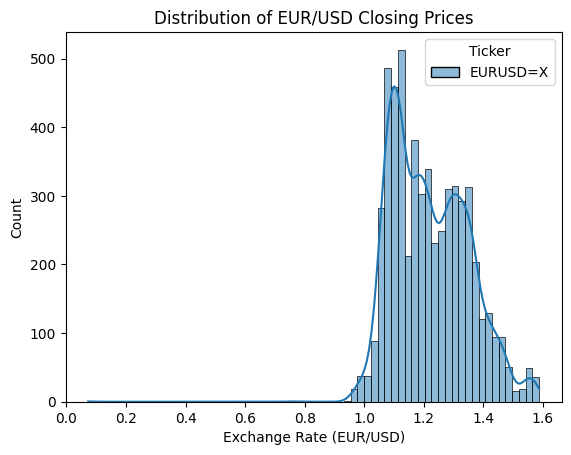

In [79]:
sns.histplot(data['Low'], kde=True)
plt.title("Distribution of EUR/USD Closing Prices")
plt.xlabel("Exchange Rate (EUR/USD)")
plt.show()




In [80]:
data_ = data[data['Low']<=0.8]['Low']

filtered_data = data_.dropna()

filtered_data


Ticker,EURUSD=X
Date,
2008-03-17,0.072902
2012-01-27,0.760572


In [81]:
dates_to_fix = date_list = filtered_data.index.tolist()


for date in dates_to_fix:
    prev_date = data.index[data.index.get_loc(date) - 1]
    next_date = data.index[data.index.get_loc(date) + 1]

        
    avg_value = (data.loc[prev_date, 'Low'] + data.loc[next_date, 'Low']) / 2

        
    data.loc[date,'Low'] = float(avg_value.iloc[0])

print(data.loc[dates_to_fix, 'Low'])


Ticker      EURUSD=X
Date                
2008-03-17  1.557800
2012-01-27  1.308935


In [ ]:
Low = data['Low']
Low

Ticker,EURUSD=X
Date,
2003-12-01,1.194401
2003-12-02,1.194600
2003-12-03,1.207700
2003-12-04,1.204398
2003-12-05,1.206593
...,...
2025-10-17,1.165814
2025-10-20,1.164538
2025-10-21,1.159851


Mean Squared Error: 0.003311
R² Score: -0.307260


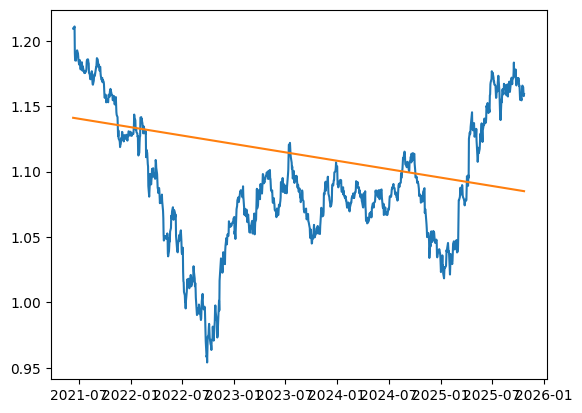

In [99]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

df = Low.copy()


# Convert dates to numeric
X = np.array([d.toordinal() for d in df.index]).reshape(-1, 1)
y = df.values

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Prediction
y_pred = model.predict(X_test_scaled)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.6f}")
print(f"R² Score: {r2:.6f}")


plt.plot(df.index[len(X_train):], y_test)
plt.plot(df.index[len(X_train):], y_pred)
plt.show()